# TVET Bangladesh Teacher Survey — Exploratory Data Analysis

Comprehensive analysis of survey responses from **1,301 TVET teachers** across
polytechnic institutes in Bangladesh.

**Research focus:**
- Distribution of educational qualifications among TVET teachers
- Training and certification participation rates and types
- Adoption of Bloom's Taxonomy in classroom teaching
- Usage of blended learning approaches
- Departmental composition across institutions
- Cross-variable relationships and policy-relevant patterns

**Data source:** `data/TVET_Teachers.xlsx`
**Figures saved to:** `figures/` (300 DPI PNG + PDF, journal-ready)

> Run cells **top-to-bottom** in order. All figures are auto-saved to `figures/`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

from src.data_loader import (
    load_data, load_data_with_timestamp, load_student_data,
    get_training_counts, get_crosstab_pct,
)
from src.visualizations import (
    plot_pie, plot_bar_pie, plot_bar_annotated, plot_heatmap, save_figure
)

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)
print("Imports OK")

Imports OK


## 1. Dataset Overview

Before plotting, we examine dataset structure, completeness, and baseline distributions
for every variable.

In [2]:
df = load_data()
print(f"Respondents : {df.shape[0]:,}")
print(f"Variables   : {df.shape[1]}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Respondents : 1,301
Variables   : 7

Columns: ['Education', 'TrainingCompleted', 'TrainingDetails', 'Institution', 'BloomsTaxonomy', 'BlendedLearning', 'Department']


,Education,TrainingCompleted,TrainingDetails,Institution,BloomsTaxonomy,BlendedLearning,Department
0,Master's,Yes,"Advanced pedagogy in TVET, Basic training course",Dhaka Govt. Polytechnic Institute,Yes,Yes,Non Technical
1,Bachelor's,Yes,Basic training course,Dhaka Govt. Polytechnic Institute,No,No,Chemical
2,Master's,No,NaN,Dhaka Govt. Polytechnic Institute,I Don't Know,Yes,Non Technical
3,Bachelor's,No,NaN,Dhaka Govt. Polytechnic Institute,No,No,Non Technical
4,Bachelor's,No,NaN,Dhaka Govt. Polytechnic Institute,I Don't Know,Yes,Chemical


In [3]:
print("Missing Value Analysis")
print("=" * 45)
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(1)
quality = pd.DataFrame({"Missing Count": missing, "Missing (%)": pct})
display(quality)
print("\nNote: TrainingDetails is expected to be missing for teachers")
print("      who answered 'No' to TrainingCompleted.")

Missing Value Analysis


,Missing Count,Missing (%)
Education,0,0.00
TrainingCompleted,0,0.00
TrainingDetails,517,39.70
Institution,0,0.00
BloomsTaxonomy,0,0.00
BlendedLearning,0,0.00
Department,0,0.00



Note: TrainingDetails is expected to be missing for teachers
      who answered 'No' to TrainingCompleted.


In [4]:
print("Variable Distributions")
print("=" * 55)
for col in ["Education", "TrainingCompleted", "BloomsTaxonomy", "BlendedLearning", "Department"]:
    counts = df[col].value_counts()
    print(f"\n{col}:")
    for label, count in counts.items():
        print(f"  {str(label):<38} {count:>5}  ({count / len(df) * 100:.1f}%)")

Variable Distributions

Education:
  Master's                                 547  (42.0%)
  Bachelor's                               433  (33.3%)
  Diploma                                  321  (24.7%)

TrainingCompleted:
  Yes                                      784  (60.3%)
  No                                       517  (39.7%)

BloomsTaxonomy:
  No                                       491  (37.7%)
  I Don't Know                             491  (37.7%)
  Yes                                      319  (24.5%)

BlendedLearning:
  I Don't Know                             553  (42.5%)
  No                                       526  (40.4%)
  Yes                                      222  (17.1%)

Department:
  Non Technical                            488  (37.5%)
  Computer                                 222  (17.1%)
  Civil                                    125  (9.6%)
  Electronics                              112  (8.6%)
  Electrical                                77  (5.9%)
  RA

## 2. Fig 1 — Distribution of Educational Qualification

Examines the highest academic degree held by TVET teachers across the surveyed
institutions. This establishes the baseline academic profile of the workforce.

Saved → /home/abhowmik/Desktop/TVET_BD/figures/Fig1.png


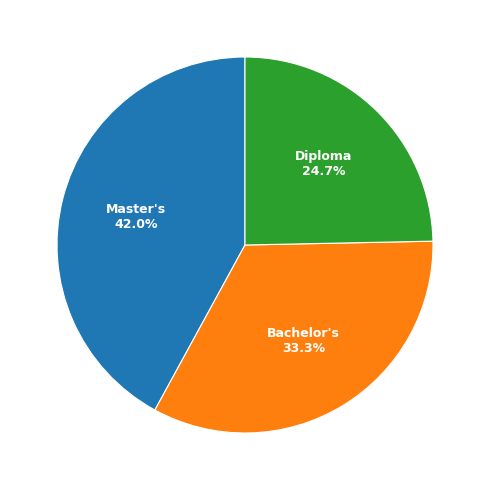


Breakdown:
  Master's: 547 (42.0%)
  Bachelor's: 433 (33.3%)
  Diploma: 321 (24.7%)


In [5]:
education_counts = df["Education"].value_counts()

fig = plot_pie(education_counts, figsize=(5, 5))
save_figure(fig, "Fig1")
plt.show()

print("\nBreakdown:")
for label, count in education_counts.items():
    print(f"  {label}: {count:,} ({count / education_counts.sum() * 100:.1f}%)")

**Insight:** The educational profile of TVET teachers reflects the qualification
requirements for polytechnic faculty. A concentration in Bachelor's or Master's degrees
suggests that most teachers have the academic foundation for modern pedagogy; however,
holding a degree does not automatically translate to pedagogical awareness (e.g., Bloom's
Taxonomy), which is explored in later sections.

## 3. Fig 2 — Training and Certification Participation

Captures the proportion of teachers who have completed at least one training,
certification, or professional workshop.

Saved → /home/abhowmik/Desktop/TVET_BD/figures/Fig2.png


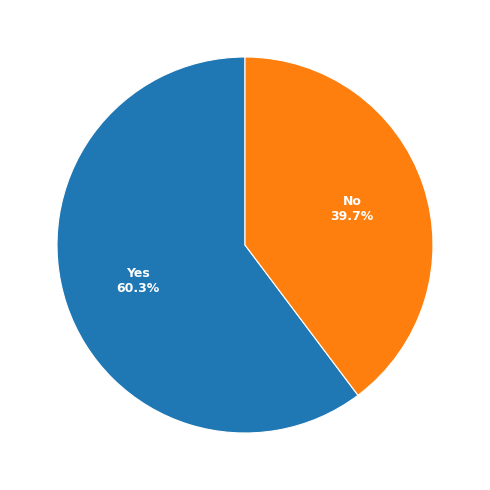


Trained     : 784 (60.3%)
Not trained : 517 (39.7%)


In [6]:
training_completion_counts = df["TrainingCompleted"].value_counts()

fig = plot_pie(training_completion_counts, figsize=(5, 5))
save_figure(fig, "Fig2")
plt.show()

trained     = training_completion_counts.get("Yes", 0)
not_trained = training_completion_counts.get("No", 0)
total = trained + not_trained
print(f"\nTrained     : {trained:,} ({trained / total * 100:.1f}%)")
print(f"Not trained : {not_trained:,} ({not_trained / total * 100:.1f}%)")

**Insight:** The training participation rate is a direct indicator of professional
development engagement within TVET institutions. A significant share of untrained teachers
suggests systemic gaps — potentially due to limited access, institutional support, or
awareness of available programmes. This gap is particularly concerning given the
pedagogical complexity required for vocational education delivery.

## 4. Fig 3 — Types of Trainings Completed

Among teachers who have participated in professional development, this section identifies
the specific programmes attended. A single teacher may appear in multiple categories.

In [7]:
training_counts_df = get_training_counts(df)
print("Training type distribution (counts across all 1,301 respondents):\n")
print(training_counts_df.to_string(index=False))
print(f"\nTotal training completions logged : {training_counts_df['Count'].sum():,}")
print("(> number of trained teachers because multiple trainings per teacher)")

Training type distribution (counts across all 1,301 respondents):

                  Training  Count
       Foundation training    542
     Basic training course    535
    International training    376
             NTVQF Level 1    349
            Other Training     90
Basic procurement training     72
             NTVQF Level 3     51
          Procuring Entity     33
 Advanced pedagogy in TVET     17
             NTVQF Level 2      0

Total training completions logged : 2,065
(> number of trained teachers because multiple trainings per teacher)


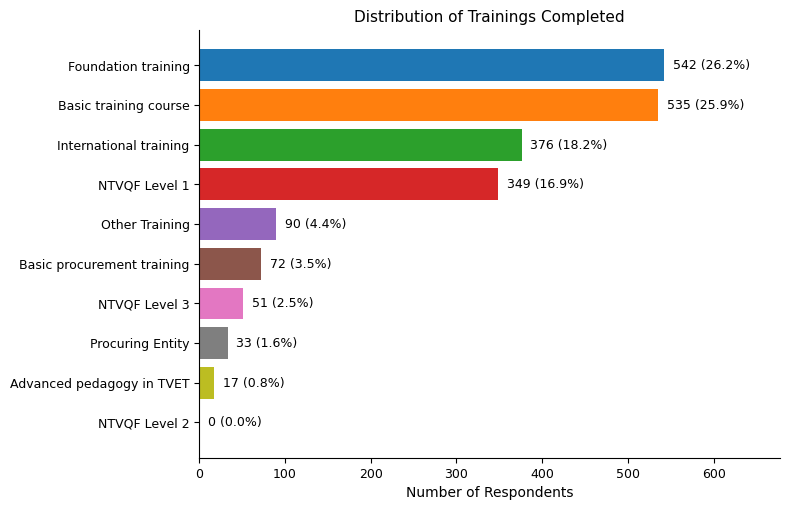

In [8]:
fig = plot_bar_annotated(
    training_counts_df.set_index("Training")["Count"],
    figsize=(8, 5),
)
fig.axes[0].set_title("Distribution of Trainings Completed", fontsize=11)
plt.show()

Saved → /home/abhowmik/Desktop/TVET_BD/figures/Fig3.png


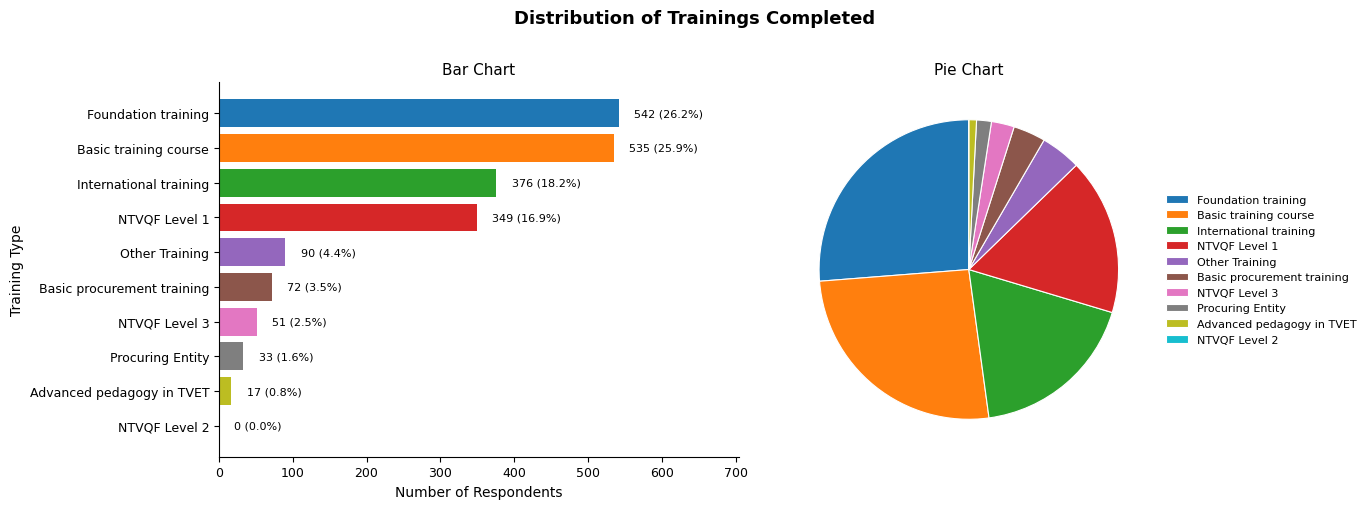

In [9]:
fig = plot_bar_pie(
    labels=training_counts_df["Training"],
    values=training_counts_df["Count"],
    suptitle="Distribution of Trainings Completed",
    bar_ylabel="Training Type",
    figsize=(14, 5),
)
save_figure(fig, "Fig3")
plt.show()

**Insight:** The dominance of foundational programmes (Basic Training Course, Foundation
Training) over competency-based qualifications (NTVQF Levels 1–3) reveals a gap between
basic and advanced professional development. NTVQF-level certifications are central to
Bangladesh's national TVET reform agenda; their low uptake implies that reform goals are
not yet being met at the teacher level. Scaling NTVQF-level training should be a policy
priority.

## 5. Fig 4 — Application of Bloom's Taxonomy

Bloom's Taxonomy is a hierarchical framework for classifying learning objectives, widely
used in curriculum design and assessment. This figure captures self-reported adoption
in TVET classrooms.

Saved → /home/abhowmik/Desktop/TVET_BD/figures/Fig4.png


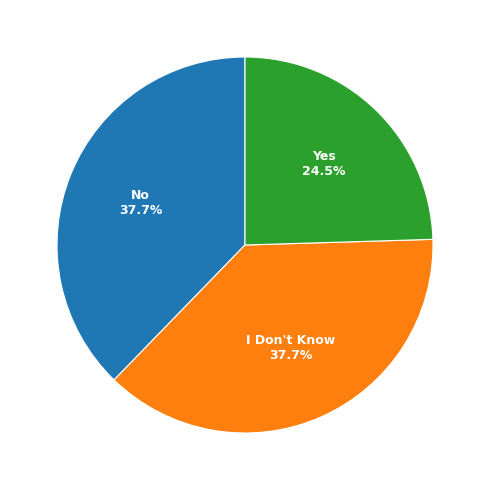


Bloom's Taxonomy application:
  No: 491 (37.7%)
  I Don't Know: 491 (37.7%)
  Yes: 319 (24.5%)


In [10]:
blooms_counts = df["BloomsTaxonomy"].value_counts()

fig = plot_pie(blooms_counts, figsize=(5, 5))
save_figure(fig, "Fig4")
plt.show()

print("\nBloom's Taxonomy application:")
for label, count in blooms_counts.items():
    print(f"  {label}: {count:,} ({count / blooms_counts.sum() * 100:.1f}%)")

**Insight:** The proportion responding *"I Don't Know"* is critically important — it
signals an *awareness gap*, not merely an application gap. Teachers who are unaware of
the framework cannot self-select to adopt it. This has direct implications for pre-service
and in-service training design: awareness and orientation sessions should precede
skill-application training. The combined "No" + "I Don't Know" group represents a
substantial development target.

## 6. Fig 5 — Adoption of Blended Learning

Blended learning integrates face-to-face instruction with digital or online components.
This section captures current uptake and its implications for institutional ICT readiness.

Saved → /home/abhowmik/Desktop/TVET_BD/figures/Fig5.png


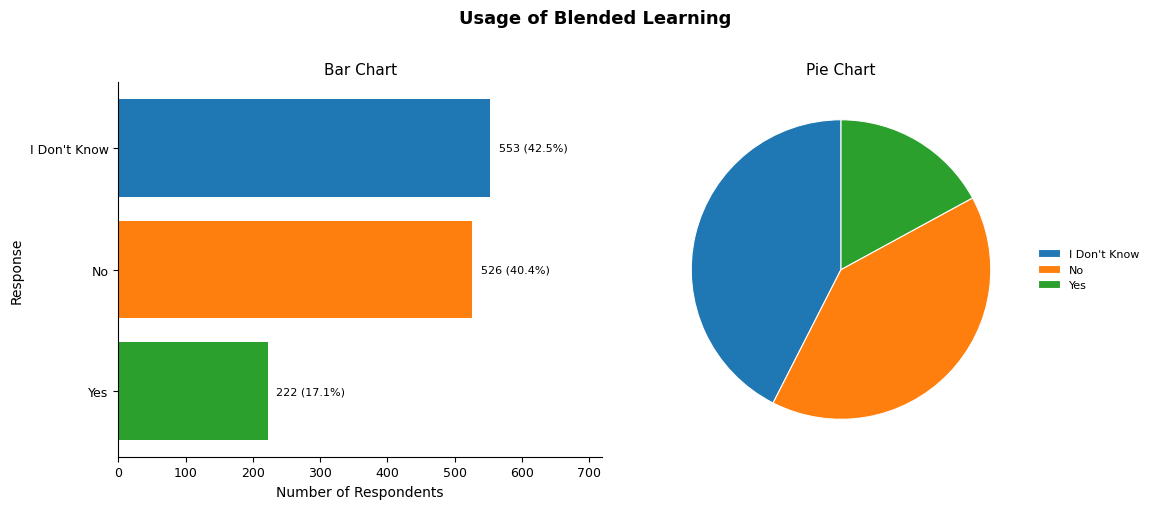


Blended Learning adoption:
  I Don't Know: 553 (42.5%)
  No: 526 (40.4%)
  Yes: 222 (17.1%)


In [11]:
blended_counts = df["BlendedLearning"].value_counts()

fig = plot_bar_pie(
    labels=blended_counts.index,
    values=blended_counts.values,
    suptitle="Usage of Blended Learning",
    bar_ylabel="Response",
    figsize=(12, 5),
)
save_figure(fig, "Fig5")
plt.show()

print("\nBlended Learning adoption:")
for label, count in blended_counts.items():
    print(f"  {label}: {count:,} ({count / blended_counts.sum() * 100:.1f}%)")

**Insight:** Blended learning adoption is a proxy for institutional ICT readiness
and teacher digital literacy. Low adoption likely reflects a combination of infrastructure
barriers (limited internet, absence of LMS platforms), lack of training in digital
pedagogy tools, and possibly conservative institutional culture. Policy responses should
address both the supply side (infrastructure, tools) and the demand side (teacher
upskilling, awareness).

## 7. Fig 6 — Departmental Distribution

Distribution of survey respondents across academic departments, reflecting the
disciplinary composition of TVET faculty.

Saved → /home/abhowmik/Desktop/TVET_BD/figures/Fig6.png


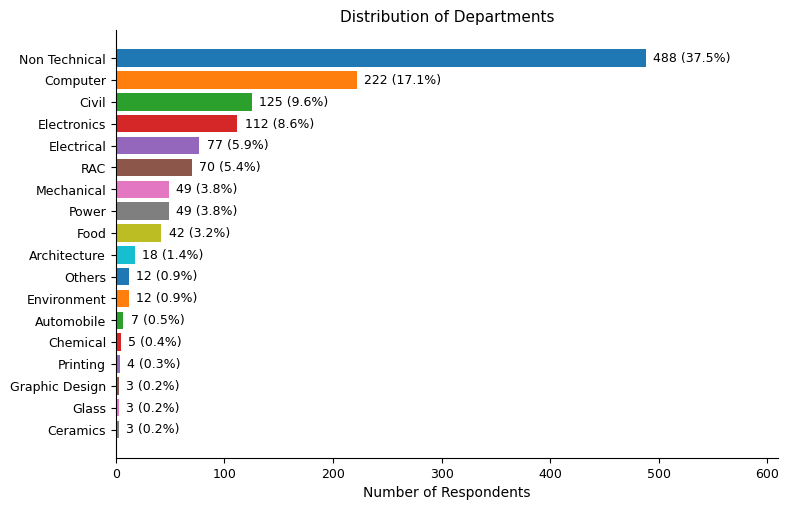


Departments represented : 18
Largest department      : Non Technical (488)
Smallest department     : Ceramics (3)


In [12]:
department_counts = df["Department"].value_counts()

fig = plot_bar_annotated(department_counts, figsize=(8, 5))
fig.axes[0].set_title("Distribution of Departments", fontsize=11)
save_figure(fig, "Fig6")
plt.show()

print(f"\nDepartments represented : {len(department_counts)}")
print(f"Largest department      : {department_counts.index[0]} ({department_counts.iloc[0]:,})")
print(f"Smallest department     : {department_counts.index[-1]} ({department_counts.iloc[-1]:,})")

**Insight:** The "Non-Technical" department typically encompasses general/foundational
studies, administrative staff, and cross-cutting subject teachers. The spread across
engineering departments (Civil, Electrical, Mechanical, Computer, etc.) determines
where targeted professional development programmes should be concentrated. Departments
with lower representation may face resource allocation challenges.

## 8. Cross-tabulation Analysis

This section systematically examines relationships between pairs of variables to surface
patterns relevant to policy and institutional planning. Row percentages are used throughout
(i.e., *within* each row group, what is the distribution across columns?).

### 8.1 — Training Completion by Department

Which departments have the highest and lowest rates of trained teachers?

Training Completion by Department (row %)


TrainingCompleted,No,Yes
Department,,
Architecture,55.6,44.4
Automobile,71.4,28.6
Ceramics,0.0,100.0
Chemical,80.0,20.0
Civil,40.0,60.0
Computer,41.0,59.0
Electrical,33.8,66.2
Electronics,41.1,58.9
Environment,50.0,50.0


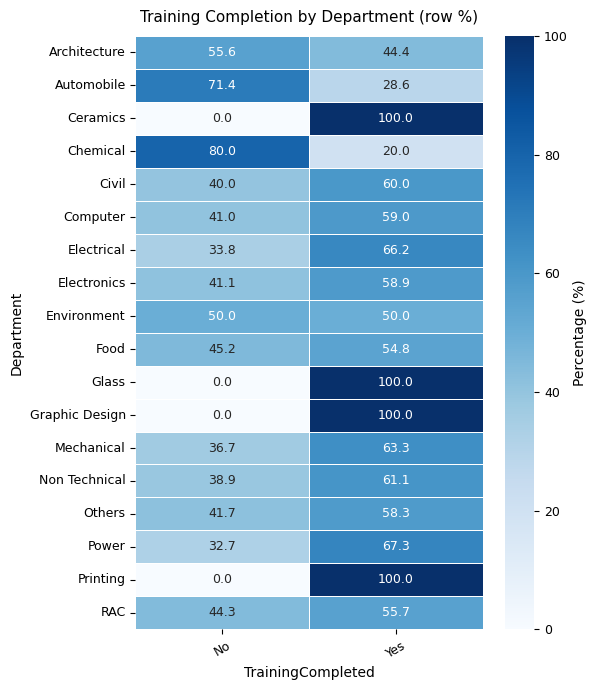


Departments ranked by training participation rate (%):
  Printing                       100.0%
  Ceramics                       100.0%
  Graphic Design                 100.0%
  Glass                          100.0%
  Power                          67.3%
  Electrical                     66.2%
  Mechanical                     63.3%
  Non Technical                  61.1%
  Civil                          60.0%
  Computer                       59.0%
  Electronics                    58.9%
  Others                         58.3%
  RAC                            55.7%
  Food                           54.8%
  Environment                    50.0%
  Architecture                   44.4%
  Automobile                     28.6%
  Chemical                       20.0%


In [13]:
ct = get_crosstab_pct(df, "Department", "TrainingCompleted")
print("Training Completion by Department (row %)")
display(ct.style.format("{:.1f}").background_gradient(cmap="Blues", axis=1))

fig = plot_heatmap(ct, "Training Completion by Department (row %)",
                   figsize=(6, 7), cmap="Blues")
plt.show()

# Rank departments by training rate
if "Yes" in ct.columns:
    ranked = ct["Yes"].sort_values(ascending=False)
    print("\nDepartments ranked by training participation rate (%):")
    for dept, pct in ranked.items():
        print(f"  {dept:<30} {pct:.1f}%")

### 8.2 — Training Completion by Education Level

Do higher qualifications correlate with higher training participation?

Training Completion by Education Level (row %)


TrainingCompleted,No,Yes
Education,,
Bachelor's,42.5,57.5
Diploma,39.9,60.1
Master's,37.5,62.5


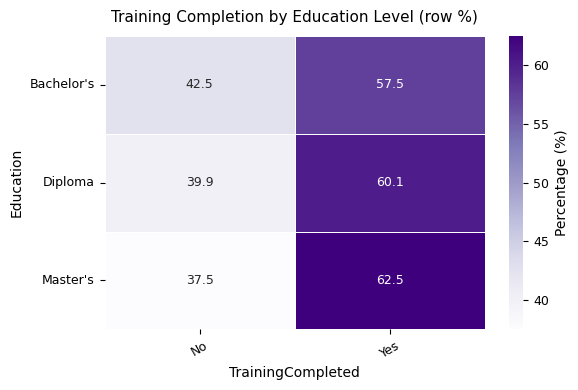

In [14]:
ct = get_crosstab_pct(df, "Education", "TrainingCompleted")
print("Training Completion by Education Level (row %)")
display(ct.style.format("{:.1f}").background_gradient(cmap="Purples", axis=1))

fig = plot_heatmap(ct, "Training Completion by Education Level (row %)",
                   figsize=(6, 4), cmap="Purples")
plt.show()

### 8.3 — Bloom's Taxonomy Application by Training Status

Does having formal training increase Bloom's Taxonomy adoption?
This is one of the most policy-relevant relationships in the dataset.

Bloom's Taxonomy by Training Status (row %)


BloomsTaxonomy,I Don't Know,No,Yes
TrainingCompleted,,,
No,85.5,8.5,6.0
Yes,6.2,57.0,36.7


Saved → /home/abhowmik/Desktop/TVET_BD/figures/Fig7.png


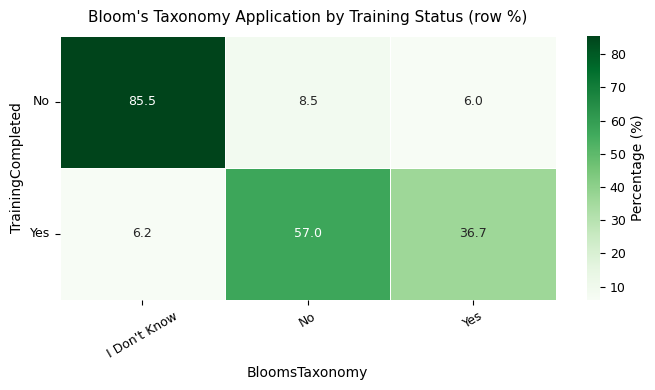


Chi-square test: χ²=832.66, df=2, p=0.0000
→ Statistically significant association (p < 0.05).


In [15]:
ct = get_crosstab_pct(df, "TrainingCompleted", "BloomsTaxonomy")
print("Bloom's Taxonomy by Training Status (row %)")
display(ct.style.format("{:.1f}").background_gradient(cmap="Greens", axis=1))

fig = plot_heatmap(ct, "Bloom's Taxonomy Application by Training Status (row %)",
                   figsize=(7, 4), cmap="Greens")
save_figure(fig, "Fig7")
plt.show()

# Chi-square test
ct_raw = pd.crosstab(df["TrainingCompleted"], df["BloomsTaxonomy"])
chi2, p, dof, _ = chi2_contingency(ct_raw)
print(f"\nChi-square test: χ²={chi2:.2f}, df={dof}, p={p:.4f}")
if p < 0.05:
    print("→ Statistically significant association (p < 0.05).")
else:
    print("→ No statistically significant association detected.")

### 8.4 — Bloom's Taxonomy Application by Education Level

Does higher academic qualification predict greater pedagogical awareness?

Bloom's Taxonomy by Education Level (row %)


BloomsTaxonomy,I Don't Know,No,Yes
Education,,,
Bachelor's,41.1,35.8,23.1
Diploma,44.2,42.7,13.1
Master's,31.3,36.4,32.4


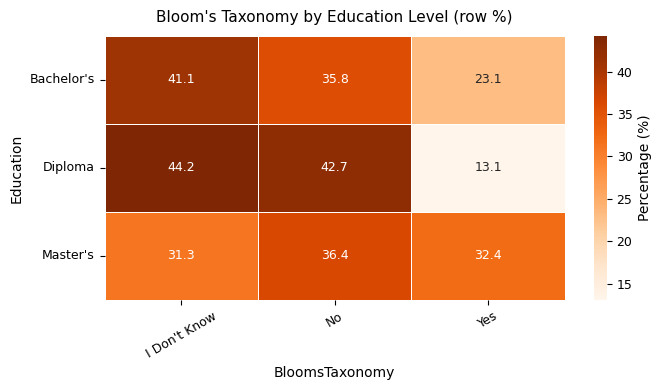


Chi-square test: χ²=44.94, df=4, p=0.0000
→ Statistically significant association (p < 0.05).


In [16]:
ct = get_crosstab_pct(df, "Education", "BloomsTaxonomy")
print("Bloom's Taxonomy by Education Level (row %)")
display(ct.style.format("{:.1f}").background_gradient(cmap="Oranges", axis=1))

fig = plot_heatmap(ct, "Bloom's Taxonomy by Education Level (row %)",
                   figsize=(7, 4), cmap="Oranges")
plt.show()

ct_raw = pd.crosstab(df["Education"], df["BloomsTaxonomy"])
chi2, p, dof, _ = chi2_contingency(ct_raw)
print(f"\nChi-square test: χ²={chi2:.2f}, df={dof}, p={p:.4f}")
if p < 0.05:
    print("→ Statistically significant association (p < 0.05).")
else:
    print("→ No statistically significant association.")

### 8.5 — Bloom's Taxonomy Application by Department

Which departments show the highest pedagogical adoption rates?

Bloom's Taxonomy by Department (row %)


BloomsTaxonomy,I Don't Know,No,Yes
Department,,,
Architecture,55.6,44.4,0.0
Automobile,71.4,28.6,0.0
Ceramics,0.0,100.0,0.0
Chemical,80.0,20.0,0.0
Civil,39.2,38.4,22.4
Computer,41.4,34.2,24.3
Electrical,41.6,36.4,22.1
Electronics,44.6,36.6,18.8
Environment,50.0,25.0,25.0


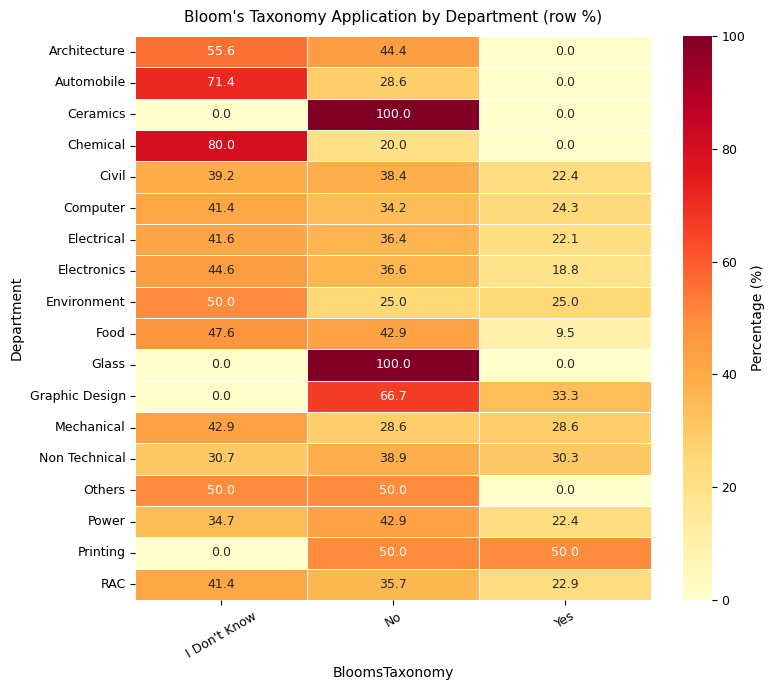


Departments ranked by Bloom's Taxonomy adoption rate (%):
  Printing                       50.0%
  Graphic Design                 33.3%
  Non Technical                  30.3%
  Mechanical                     28.6%
  Environment                    25.0%
  Computer                       24.3%
  RAC                            22.9%
  Civil                          22.4%
  Power                          22.4%
  Electrical                     22.1%
  Electronics                    18.8%
  Food                           9.5%
  Automobile                     0.0%
  Architecture                   0.0%
  Chemical                       0.0%
  Ceramics                       0.0%
  Glass                          0.0%
  Others                         0.0%


In [17]:
ct = get_crosstab_pct(df, "Department", "BloomsTaxonomy")
print("Bloom's Taxonomy by Department (row %)")
display(ct.style.format("{:.1f}").background_gradient(cmap="YlOrRd", axis=1))

fig = plot_heatmap(ct, "Bloom's Taxonomy Application by Department (row %)",
                   figsize=(8, 7), cmap="YlOrRd")
plt.show()

if "Yes" in ct.columns:
    ranked = ct["Yes"].sort_values(ascending=False)
    print("\nDepartments ranked by Bloom's Taxonomy adoption rate (%):")
    for dept, pct in ranked.items():
        print(f"  {dept:<30} {pct:.1f}%")

### 8.6 — Blended Learning Usage by Education Level

Does educational qualification predict adoption of digital teaching methods?

Blended Learning by Education Level (row %)


BlendedLearning,I Don't Know,No,Yes
Education,,,
Bachelor's,44.3,27.9,27.7
Diploma,52.0,34.3,13.7
Master's,35.5,53.9,10.6


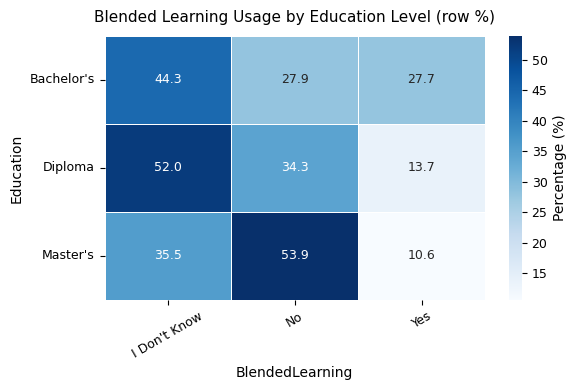


Chi-square test: χ²=102.21, df=4, p=0.0000
→ Statistically significant association (p < 0.05).


In [18]:
ct = get_crosstab_pct(df, "Education", "BlendedLearning")
print("Blended Learning by Education Level (row %)")
display(ct.style.format("{:.1f}").background_gradient(cmap="Blues", axis=1))

fig = plot_heatmap(ct, "Blended Learning Usage by Education Level (row %)",
                   figsize=(6, 4), cmap="Blues")
plt.show()

ct_raw = pd.crosstab(df["Education"], df["BlendedLearning"])
chi2, p, dof, _ = chi2_contingency(ct_raw)
print(f"\nChi-square test: χ²={chi2:.2f}, df={dof}, p={p:.4f}")
if p < 0.05:
    print("→ Statistically significant association (p < 0.05).")
else:
    print("→ No statistically significant association.")

### 8.7 — Blended Learning Usage by Department

Which departments are leading in technology-enabled instruction?

Blended Learning by Department (row %)


BlendedLearning,I Don't Know,No,Yes
Department,,,
Architecture,50.0,22.2,27.8
Automobile,85.7,14.3,0.0
Ceramics,0.0,66.7,33.3
Chemical,60.0,20.0,20.0
Civil,47.2,50.4,2.4
Computer,41.9,4.1,54.1
Electrical,45.5,45.5,9.1
Electronics,46.4,27.7,25.9
Environment,50.0,25.0,25.0


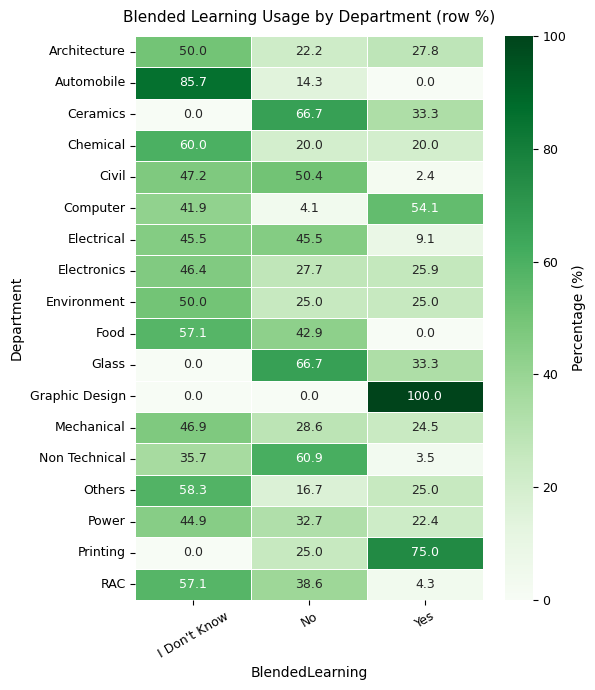


Departments ranked by blended learning adoption rate (%):
  Graphic Design                 100.0%
  Printing                       75.0%
  Computer                       54.1%
  Ceramics                       33.3%
  Glass                          33.3%
  Architecture                   27.8%
  Electronics                    25.9%
  Others                         25.0%
  Environment                    25.0%
  Mechanical                     24.5%
  Power                          22.4%
  Chemical                       20.0%
  Electrical                     9.1%
  RAC                            4.3%
  Non Technical                  3.5%
  Civil                          2.4%
  Automobile                     0.0%
  Food                           0.0%


In [19]:
ct = get_crosstab_pct(df, "Department", "BlendedLearning")
print("Blended Learning by Department (row %)")
display(ct.style.format("{:.1f}").background_gradient(cmap="Greens", axis=1))

fig = plot_heatmap(ct, "Blended Learning Usage by Department (row %)",
                   figsize=(6, 7), cmap="Greens")
plt.show()

if "Yes" in ct.columns:
    ranked = ct["Yes"].sort_values(ascending=False)
    print("\nDepartments ranked by blended learning adoption rate (%):")
    for dept, pct in ranked.items():
        print(f"  {dept:<30} {pct:.1f}%")

### 8.8 — Bloom's Taxonomy vs. Blended Learning

Do teachers who use blended learning also apply Bloom's Taxonomy more?
This tests whether modern pedagogical practices co-occur.

Bloom's Taxonomy by Blended Learning usage (row %)


BloomsTaxonomy,I Don't Know,No,Yes
BlendedLearning,,,
I Don't Know,80.8,18.1,1.1
No,3.2,56.8,39.9
Yes,12.2,41.4,46.4


Saved → /home/abhowmik/Desktop/TVET_BD/figures/Fig8.png


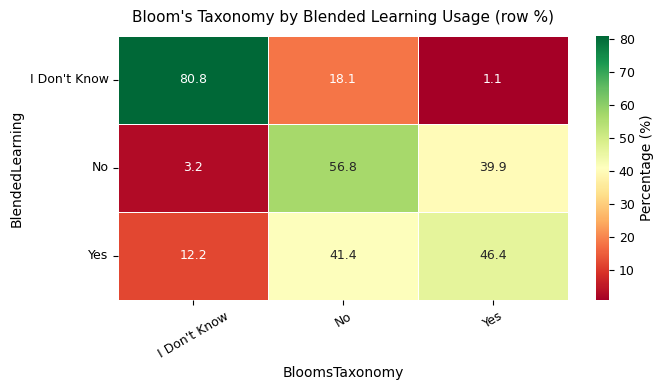


Chi-square test: χ²=802.93, df=4, p=0.0000
→ Statistically significant co-occurrence (p < 0.05).
  Teachers using blended learning are more likely to also apply Bloom's Taxonomy.


In [20]:
ct = get_crosstab_pct(df, "BlendedLearning", "BloomsTaxonomy")
print("Bloom's Taxonomy by Blended Learning usage (row %)")
display(ct.style.format("{:.1f}").background_gradient(cmap="RdYlGn", axis=1))

fig = plot_heatmap(ct, "Bloom's Taxonomy by Blended Learning Usage (row %)",
                   figsize=(7, 4), cmap="RdYlGn")
save_figure(fig, "Fig8")
plt.show()

ct_raw = pd.crosstab(df["BlendedLearning"], df["BloomsTaxonomy"])
chi2, p, dof, _ = chi2_contingency(ct_raw)
print(f"\nChi-square test: χ²={chi2:.2f}, df={dof}, p={p:.4f}")
if p < 0.05:
    print("→ Statistically significant co-occurrence (p < 0.05).")
    print("  Teachers using blended learning are more likely to also apply Bloom's Taxonomy.")
else:
    print("→ No statistically significant co-occurrence.")

### 8.9 — Top Institutions by Training Participation Rate

Which polytechnic institutes have the highest staff training uptake?

Institutions with ≥10 respondents, ranked by training participation rate:

                                                          N  Trained (%)  Not Trained (%)
Institution                                                                              
Patuakhali Govt. Polytechnic Institute                   21       100.00             0.00
Thakurgaon Govt. Polytechnic Institute                   14       100.00             0.00
Govt. Graphic Arts Institute                             32       100.00             0.00
Govt. Institute of Glass and Ceramics                    17       100.00             0.00
Dinajpur Govt. Polytechnic Institute                     19       100.00             0.00
Dhaka Govt. Mohila Polytechnic Institute                 42       100.00             0.00
Naogaon Govt. Polytechnic Institute                      22        90.90             9.10
Bogura Govt. Polytechnic Institute, Bogura               52        78.80            21.20
Sirajganj Govt. Polytechn

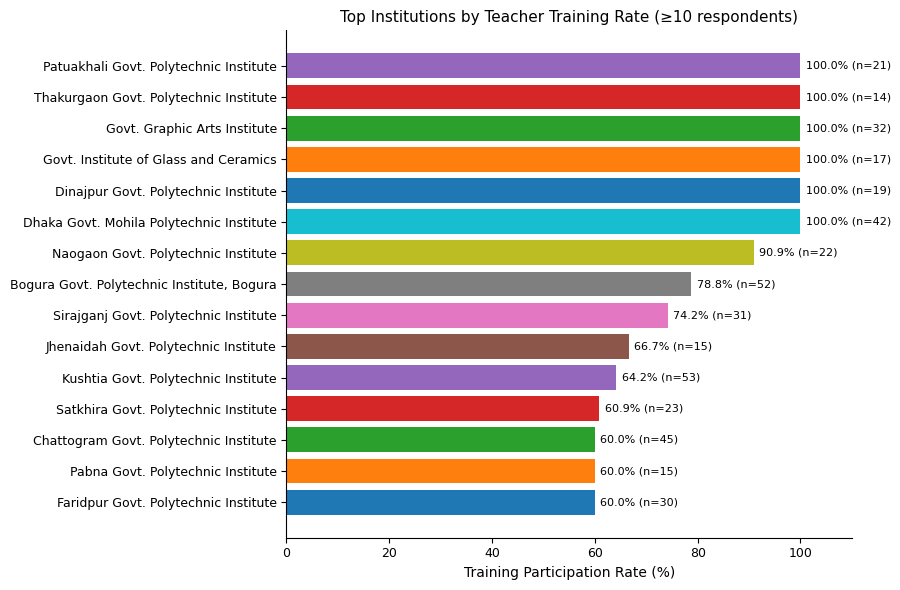

In [21]:
inst_stats = (
    df.groupby("Institution")["TrainingCompleted"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .mul(100)
    .round(1)
)
inst_counts = df["Institution"].value_counts().rename("N")
inst_stats = inst_stats.join(inst_counts)

# Show institutions with at least 10 respondents, ranked by training rate
if "Yes" in inst_stats.columns:
    inst_filtered = inst_stats[inst_stats["N"] >= 10].sort_values("Yes", ascending=False)
    print("Institutions with ≥10 respondents, ranked by training participation rate:\n")
    print(inst_filtered[["N", "Yes", "No"]].rename(
        columns={"Yes": "Trained (%)", "No": "Not Trained (%)"}
    ).to_string())

    # Bar chart of top 15
    top15 = inst_filtered.head(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    colors = sns.color_palette("tab10", len(top15))
    ax.barh(top15.index[::-1], top15["Yes"][::-1], color=colors)
    ax.set_xlabel("Training Participation Rate (%)", fontsize=10)
    ax.set_title("Top Institutions by Teacher Training Rate (≥10 respondents)", fontsize=11)
    ax.set_xlim(0, 110)
    for idx, (inst, row) in enumerate(top15.iloc[::-1].iterrows()):
        ax.text(row["Yes"] + 1, idx, f"{row['Yes']:.1f}% (n={int(row['N'])})",
                va="center", fontsize=8)
    fig.tight_layout()
    plt.show()

### 8.10 — Education Level by Department

What is the qualification profile within each department?
This reveals whether certain departments draw more postgraduate-qualified staff.

Education Level by Department (row %)


Education,Bachelor's,Diploma,Master's
Department,,,
Architecture,38.9,61.1,0.0
Automobile,14.3,85.7,0.0
Ceramics,33.3,66.7,0.0
Chemical,40.0,60.0,0.0
Civil,49.6,48.0,2.4
Computer,50.5,23.4,26.1
Electrical,51.9,42.9,5.2
Electronics,59.8,34.8,5.4
Environment,25.0,33.3,41.7


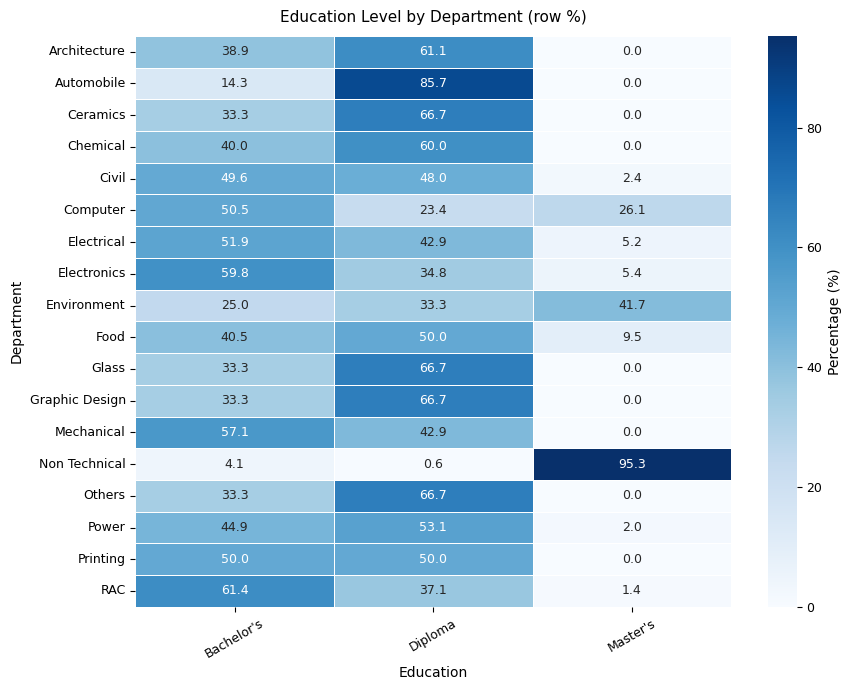

In [22]:
ct = get_crosstab_pct(df, "Department", "Education")
print("Education Level by Department (row %)")
display(ct.style.format("{:.1f}").background_gradient(cmap="Blues", axis=1))

fig = plot_heatmap(ct, "Education Level by Department (row %)",
                   figsize=(9, 7), cmap="Blues")
plt.show()

### 8.11 — Blended Learning by Training Status

Does formal training predict adoption of blended learning?

Blended Learning by Training Status (row %)


BlendedLearning,I Don't Know,No,Yes
TrainingCompleted,,,
No,82.2,13.5,4.3
Yes,16.3,58.2,25.5


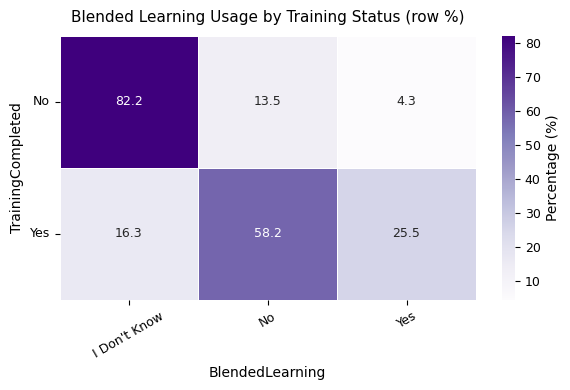


Chi-square test: χ²=554.03, df=2, p=0.0000
→ Statistically significant association (p < 0.05).
  Trained teachers are more (or less) likely to use blended learning.


In [23]:
ct = get_crosstab_pct(df, "TrainingCompleted", "BlendedLearning")
print("Blended Learning by Training Status (row %)")
display(ct.style.format("{:.1f}").background_gradient(cmap="Purples", axis=1))

fig = plot_heatmap(ct, "Blended Learning Usage by Training Status (row %)",
                   figsize=(6, 4), cmap="Purples")
plt.show()

ct_raw = pd.crosstab(df["TrainingCompleted"], df["BlendedLearning"])
chi2, p, dof, _ = chi2_contingency(ct_raw)
print(f"\nChi-square test: χ²={chi2:.2f}, df={dof}, p={p:.4f}")
if p < 0.05:
    print("→ Statistically significant association (p < 0.05).")
    print("  Trained teachers are more (or less) likely to use blended learning.")
else:
    print("→ No statistically significant association.")

## 9. Summary of Key Insights

### 8.12 — Temporal Analysis: Survey Response Patterns

The original survey file includes submission timestamps (Oct 27 – Dec 4, 2024).
Analysing *when* responses were collected reveals collection bursts (likely tied
to institutional reminders) and lets us test whether response characteristics
differ across the collection window.

In [24]:
df_ts = load_data_with_timestamp()
df_ts["Date"] = df_ts["Timestamp"].dt.normalize()
df_ts["Week"]  = df_ts["Timestamp"].dt.to_period("W")

daily = df_ts.groupby("Date").size().rename("Responses")
print(f"Survey window: {df_ts['Timestamp'].min().date()} → {df_ts['Timestamp'].max().date()}")
print(f"Total responses: {len(df_ts):,}\n")
print("Daily response counts:")
print(daily.to_string())

Survey window: 2024-10-27 → 2024-12-04
Total responses: 1,301

Daily response counts:
Date
2024-10-27      1
2024-11-03      9
2024-11-04     19
2024-11-05     59
2024-11-06      2
2024-11-07      2
2024-11-10     10
2024-11-11      4
2024-11-12      2
2024-11-14      2
2024-11-15      1
2024-11-17      9
2024-11-18      5
2024-11-19     57
2024-11-20    134
2024-11-21    232
2024-11-22      8
2024-11-23    298
2024-11-24    131
2024-11-25    255
2024-11-26      1
2024-12-02      1
2024-12-04     59


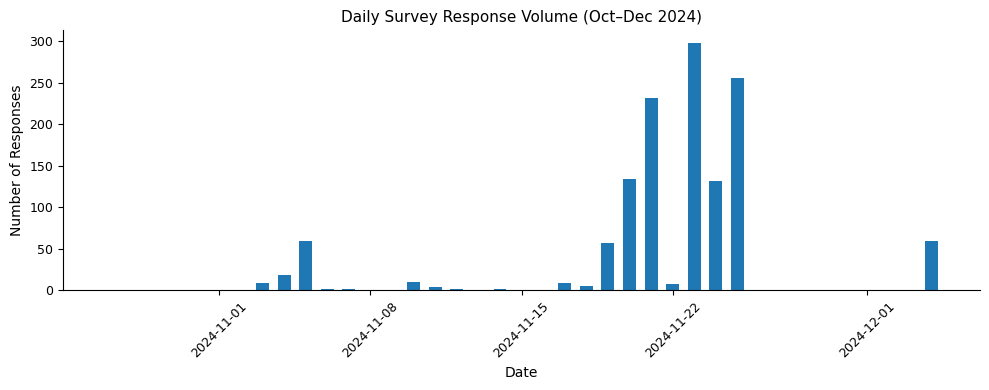

Top 3 collection days:
  2024-11-23  →  298 responses (22.9%)
  2024-11-25  →  255 responses (19.6%)
  2024-11-21  →  232 responses (17.8%)


In [25]:
# Daily response volume bar chart
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(daily.index, daily.values, color=sns.color_palette("tab10")[0], width=0.6)
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Number of Responses", fontsize=10)
ax.set_title("Daily Survey Response Volume (Oct–Dec 2024)", fontsize=11)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

# Annotate the peak days
top3 = daily.nlargest(3)
print("Top 3 collection days:")
for date, count in top3.items():
    print(f"  {date.date()}  →  {count} responses ({count / len(df_ts) * 100:.1f}%)")

In [26]:
# Do responses in high-volume burst days differ from low-volume days?
# Compare training participation rate: burst days vs non-burst days
median_daily = daily.median()
burst_dates = daily[daily > median_daily].index
df_ts["IsBurstDay"] = df_ts["Date"].isin(burst_dates)

print(f"Burst days (above daily median of {int(median_daily)} responses): {len(burst_dates)}")
print(f"Non-burst days: {daily[daily <= median_daily].shape[0]}\n")

ct = get_crosstab_pct(df_ts, "IsBurstDay", "TrainingCompleted")
ct.index = ["Non-burst day", "Burst day"]
print("Training participation by collection period (row %):")
display(ct.style.format("{:.1f}").background_gradient(cmap="Blues", axis=1))

ct2 = get_crosstab_pct(df_ts, "IsBurstDay", "BloomsTaxonomy")
ct2.index = ["Non-burst day", "Burst day"]
print("\nBloom's Taxonomy adoption by collection period (row %):")
display(ct2.style.format("{:.1f}").background_gradient(cmap="Greens", axis=1))

Burst days (above daily median of 9 responses): 10
Non-burst days: 13

Training participation by collection period (row %):


TrainingCompleted,No,Yes
Non-burst day,19.1,80.9
Burst day,40.5,59.5



Bloom's Taxonomy adoption by collection period (row %):


BloomsTaxonomy,I Don't Know,No,Yes
Non-burst day,29.8,34.0,36.2
Burst day,38.0,37.9,24.1


**Insight:** The burst pattern in collection (Nov 20–25 and Dec 4 account for most responses)
likely reflects institutional survey drives or reminder campaigns. If response characteristics
differ significantly between burst and non-burst days, it may indicate a selection effect
(i.e., teachers prompted by a reminder may have different profiles than early self-motivated
respondents). This should be noted as a potential data collection limitation.

## 8.13 — Student Challenges Dataset: Overview and Standalone Analysis

A separate survey (`Challenges Faced by Students in Polytechnic Institutes...xlsx`)
was collected from **1,212 students** covering financial, social, and academic challenges.

**Why it cannot be merged with the teacher dataset:**
- Different respondent type (students vs. teachers)
- Only **1 shared institution** across 45 teacher institutions (Dhaka Govt. Polytechnic)
- No common respondent ID or linking key

The student dataset is therefore analysed **standalone** below. For the one shared
institution (Dhaka Govt. Polytechnic), high-level comparisons between teacher practice
and student experience are feasible but should be interpreted cautiously given the
ecological inference limitation.

In [27]:
df_s = load_student_data()
print(f"Student respondents : {len(df_s):,}")
print(f"Variables           : {df_s.shape[1]}")
print(f"Collection window   : {df_s['Timestamp'].min().date()} → {df_s['Timestamp'].max().date()}")
print(f"\nInstitutions represented: {df_s['Institution'].nunique()}")
print(df_s['Institution'].value_counts().to_string())
df_s.head()

Student respondents : 1,212
Variables           : 19
Collection window   : 2024-11-06 → 2024-12-11

Institutions represented: 1
Institution
Dhaka Govt. Polytechnic Institute    1212


,Timestamp,Gender,FamilyIncome,IncomeSource,WorksWhileStudying,"5. If you've ever faced financial difficulties, how have they impacted your ability?",ScholarshipAwareness,ResourceAvailability,ExternalResourceAccess,JobConfidence,SocialStigma,NegativeComments,MotivationAffected,FamilySupport,FamilySupportImpact,StressFrequency,BiggestChallenge,Department,Institution
0,2024-11-06 21:41:59.927,Male,"10,000–20,000 BDT",Agriculture,No,Other,NaN,Somewhat adequate,NaN,NaN,Yes,Yes,Yes,NaN,NaN,Weekly,Lack of resources,Chemical,Dhaka Govt. Polytechnic Institute
1,2024-11-06 21:43:57.317,Male,"Below 10,000 BDT",Agriculture,No,Other,NaN,Somewhat adequate,NaN,NaN,No,No,No,NaN,NaN,Weekly,Financial hardship,Chemical,Dhaka Govt. Polytechnic Institute
2,2024-11-06 21:45:44.503,Female,"Below 10,000 BDT",Other,No,Could not attend classes,NaN,Somewhat adequate,NaN,NaN,Yes,Yes,Yes,NaN,NaN,Daily,Financial hardship,Chemical,Dhaka Govt. Polytechnic Institute
3,2024-11-06 21:48:44.196,Female,"Below 10,000 BDT",Other,No,Could not buy materials,NaN,Somewhat adequate,NaN,NaN,Yes,Yes,Yes,NaN,NaN,Daily,Financial hardship,Chemical,Dhaka Govt. Polytechnic Institute
4,2024-11-06 21:51:47.756,Female,"20,000–30,000 BDT",Business,No,Could not buy materials,NaN,Inadequate,NaN,NaN,Yes,Yes,Yes,NaN,NaN,Weekly,Lack of resources,Chemical,Dhaka Govt. Polytechnic Institute


In [28]:
print("Student Survey — Variable Distributions")
print("=" * 55)
categorical_cols = [
    "Gender", "WorksWhileStudying", "ScholarshipAwareness",
    "ResourceAvailability", "ExternalResourceAccess", "JobConfidence",
    "SocialStigma", "NegativeComments", "MotivationAffected",
    "FamilySupport", "FamilySupportImpact", "StressFrequency",
    "BiggestChallenge", "Department"
]
for col in categorical_cols:
    if col in df_s.columns:
        counts = df_s[col].value_counts(dropna=False)
        print(f"\n{col}:")
        for label, count in counts.items():
            print(f"  {str(label):<50} {count:>5}  ({count / len(df_s) * 100:.1f}%)")

Student Survey — Variable Distributions

Gender:
  Male                                                 856  (70.6%)
  Female                                               356  (29.4%)

WorksWhileStudying:
  No                                                   950  (78.4%)
  Yes                                                  262  (21.6%)

ScholarshipAwareness:
  nan                                                 1212  (100.0%)

ResourceAvailability:
  Inadequate                                           818  (67.5%)
  Somewhat adequate                                    386  (31.8%)
  Adequate                                               8  (0.7%)

ExternalResourceAccess:
  nan                                                 1212  (100.0%)

JobConfidence:
  nan                                                 1212  (100.0%)

SocialStigma:
  Yes                                                 1061  (87.5%)
  No                                                   151  (12.5%)

NegativeC

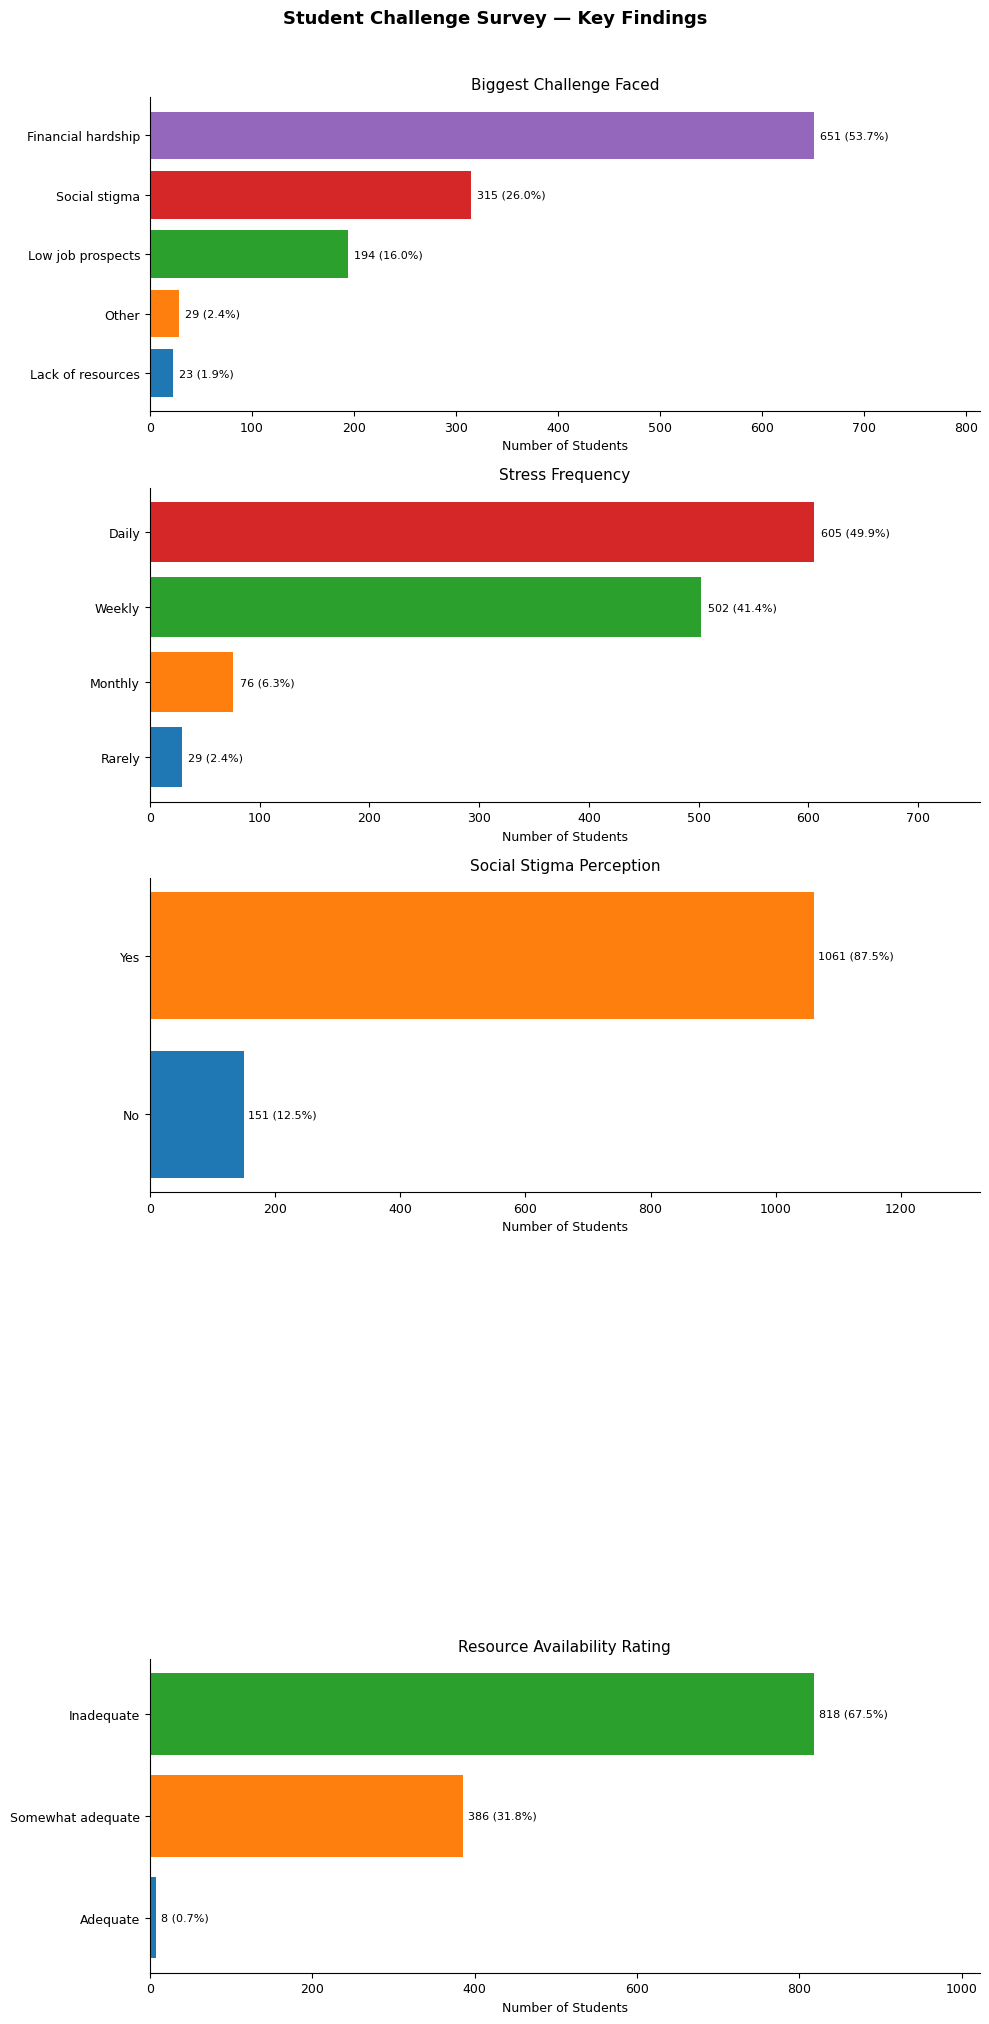

In [29]:
# Key student challenge visualisations
key_student_vars = {
    "BiggestChallenge": "Biggest Challenge Faced",
    "StressFrequency": "Stress Frequency",
    "SocialStigma": "Social Stigma Perception",
    "JobConfidence": "Confidence in Job Prospects",
    "ResourceAvailability": "Resource Availability Rating",
}

fig, axes = plt.subplots(len(key_student_vars), 1,
                          figsize=(10, 4 * len(key_student_vars)))

colors = sns.color_palette("tab10", 10)
for ax, (col, title) in zip(axes, key_student_vars.items()):
    if col not in df_s.columns:
        ax.set_visible(False)
        continue
    counts = df_s[col].value_counts(dropna=True)
    if counts.empty:
        ax.set_visible(False)
        continue
    total = counts.sum()
    ax.barh(counts.index.astype(str)[::-1], counts.values[::-1],
            color=colors[:len(counts)])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Number of Students", fontsize=9)
    for idx, val in enumerate(counts.values[::-1]):
        ax.text(val + total * 0.005, idx, f"{val} ({val/total*100:.1f}%)",
                va="center", fontsize=8)
    ax.set_xlim(0, max(counts.values) * 1.25)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Student Challenge Survey — Key Findings", fontsize=13,
             fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

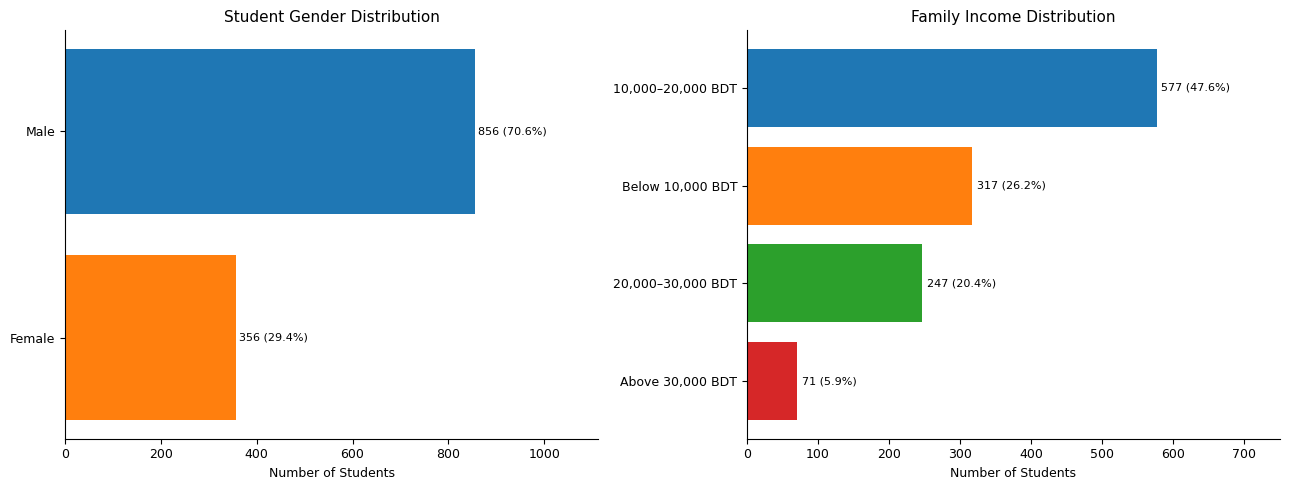

Family Support by Social Stigma Perception (row %):


SocialStigma


In [30]:
# Gender and income breakdowns
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "Gender", "Student Gender Distribution"),
    (axes[1], "FamilyIncome", "Family Income Distribution"),
]:
    if col not in df_s.columns:
        ax.set_visible(False)
        continue
    counts = df_s[col].value_counts(dropna=True)
    if counts.empty:
        ax.set_visible(False)
        continue
    colors = sns.color_palette("tab10", len(counts))
    ax.barh(counts.index.astype(str)[::-1], counts.values[::-1], color=colors[::-1])
    total = counts.sum()
    for idx, val in enumerate(counts.values[::-1]):
        ax.text(val + total * 0.005, idx, f"{val} ({val/total*100:.1f}%)",
                va="center", fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Number of Students", fontsize=9)
    ax.set_xlim(0, max(counts.values) * 1.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

# Social stigma vs family support crosstab
if "SocialStigma" in df_s.columns and "FamilySupport" in df_s.columns:
    ct_s = get_crosstab_pct(df_s, "SocialStigma", "FamilySupport")
    print("Family Support by Social Stigma Perception (row %):")
    display(ct_s.style.format("{:.1f}").background_gradient(cmap="RdYlGn", axis=1))

In [31]:
n = len(df)
edu_counts      = df["Education"].value_counts()
trained_pct     = df["TrainingCompleted"].value_counts(normalize=True).get("Yes", 0) * 100
blooms_yes_pct  = df["BloomsTaxonomy"].value_counts(normalize=True).get("Yes", 0) * 100
blooms_dk_pct   = df["BloomsTaxonomy"].value_counts(normalize=True).get("I Don't Know", 0) * 100
blended_yes_pct = df["BlendedLearning"].value_counts(normalize=True).get("Yes", 0) * 100
top_dept        = df["Department"].value_counts().index[0]
top_training    = training_counts_df.iloc[0]["Training"]   # reuse already-computed df
n_dept          = df["Department"].nunique()
n_inst          = df["Institution"].nunique()

sep = "=" * 65
print(sep)
print("KEY FINDINGS")
print(sep)

print(f"\n1. SAMPLE")
print(f"   {n:,} TVET teachers across {n_inst} polytechnic institutes")
print(f"   {n_dept} departments represented")

print(f"\n2. EDUCATIONAL QUALIFICATIONS")
for label, count in edu_counts.items():
    print(f"   {label}: {count:,} ({count / n * 100:.1f}%)")

print(f"\n3. PROFESSIONAL DEVELOPMENT")
print(f"   {trained_pct:.1f}% of teachers completed ≥1 training/certification")
print(f"   Most common programme : {top_training}")
print(f"   Least common (NTVQF)  : see Fig 3 for NTVQF Level uptake")

print(f"\n4. BLOOM'S TAXONOMY")
print(f"   {blooms_yes_pct:.1f}% apply Bloom's Taxonomy in their classrooms")
not_apply = 100 - blooms_yes_pct
print(f"   {not_apply:.1f}% do not apply it (incl. {blooms_dk_pct:.1f}% who are unaware of it)")

print(f"\n5. BLENDED LEARNING")
print(f"   {blended_yes_pct:.1f}% use blended learning approaches")
print(f"   {100 - blended_yes_pct:.1f}% rely solely on face-to-face instruction")

print("\n" + sep)
print("POLICY IMPLICATIONS")
print(sep)
print('''
1. SCALE UP PROFESSIONAL DEVELOPMENT
   A large proportion of TVET teachers have not completed any formal training.
   Structured, mandatory CPD programmes are needed across all institutions.

2. ADDRESS BLOOM'S TAXONOMY AWARENESS GAPS
   The high "I Don't Know" rate means awareness campaigns and foundational
   pedagogy modules must precede skill-application training.

3. INVEST IN DIGITAL INFRASTRUCTURE
   Low blended learning rates signal both infrastructure and digital literacy
   gaps. Targeted e-pedagogy training and LMS rollout are recommended.

4. PRIORITISE NTVQF-LEVEL COMPETENCY TRAINING
   Basic courses dominate training completions. NTVQF-level (competency-based)
   certifications -- central to national reform -- remain underutilised.

5. DEPARTMENT-TARGETED INTERVENTIONS
   Cross-tab analysis (Sections 8.1-8.7) reveals which departments lag in
   training, Bloom's adoption, and blended learning -- enabling targeted support.

6. INSTITUTIONAL BENCHMARKING
   Training participation varies significantly across institutions (Section 8.9).
   Low-performing institutions should be identified for priority support.
''')

KEY FINDINGS

1. SAMPLE
   1,301 TVET teachers across 45 polytechnic institutes
   18 departments represented

2. EDUCATIONAL QUALIFICATIONS
   Master's: 547 (42.0%)
   Bachelor's: 433 (33.3%)
   Diploma: 321 (24.7%)

3. PROFESSIONAL DEVELOPMENT
   60.3% of teachers completed ≥1 training/certification
   Most common programme : Foundation training
   Least common (NTVQF)  : see Fig 3 for NTVQF Level uptake

4. BLOOM'S TAXONOMY
   24.5% apply Bloom's Taxonomy in their classrooms
   75.5% do not apply it (incl. 37.7% who are unaware of it)

5. BLENDED LEARNING
   17.1% use blended learning approaches
   82.9% rely solely on face-to-face instruction

POLICY IMPLICATIONS

1. SCALE UP PROFESSIONAL DEVELOPMENT
   A large proportion of TVET teachers have not completed any formal training.
   Structured, mandatory CPD programmes are needed across all institutions.

2. ADDRESS BLOOM'S TAXONOMY AWARENESS GAPS
   The high "I Don't Know" rate means awareness campaigns and foundational
   pedagogy 